In [13]:
import sys
!pip install -q duckdb pandas matplotlib seaborn datasets fsspec==2026.3.0 s3fs==2026.3.0 huggingface_hub --upgrade
# Restart kernel after installation to ensure all packages are loaded correctly.
# If you are running this in Colab, you might need to restart the runtime (Runtime -> Restart runtime) after this cell runs.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.4/21.4 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.3/519.3 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 9.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 

In [14]:
import time
import warnings
warnings.filterwarnings("ignore")

import duckdb
import pandas as pd
import numpy as np
import pyarrow as pa
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

REPO_ID = "chuongdo1104/amazon-2023-bronze"


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — TẢI DỮ LIỆU TỪ HUGGING FACE + ĐĂNG KÝ DUCKDB
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("SECTION 1 — TẢI DỮ LIỆU TỪ HUGGING FACE")
print("=" * 60)

print(f"🚀 Đang tải từ: {REPO_ID}")
t0 = time.time()

try:
    tb_train = load_dataset(
        REPO_ID,
        data_files="bronze/bronze_train.parquet/**/*.parquet",
        split="train"
    ).data
    tb_val = load_dataset(
        REPO_ID,
        data_files="bronze/bronze_val.parquet/**/*.parquet",
        split="train"
    ).data
    tb_test = load_dataset(
        REPO_ID,
        data_files="bronze/bronze_test.parquet/**/*.parquet",
        split="train"
    ).data
    tb_meta = load_dataset(
        REPO_ID,
        data_files="bronze/bronze_meta.parquet",
        split="train"
    ).data

    print(f"✅ Tải thành công trong {time.time() - t0:.2f}s")

    con = duckdb.connect()
    con.register("train_tbl", pa.Table.from_batches(tb_train.to_batches()))
    con.register("val_tbl",   pa.Table.from_batches(tb_val.to_batches()))
    con.register("test_tbl",  pa.Table.from_batches(tb_test.to_batches()))
    con.register("meta_tbl",  pa.Table.from_batches(tb_meta.to_batches()))

    print("✅ Đã đăng ký 4 bảng vào DuckDB: train_tbl, val_tbl, test_tbl, meta_tbl")

    for tbl, name in [(tb_train,"train"), (tb_val,"val"), (tb_test,"test"), (tb_meta,"meta")]:
        print(f"  {name:>6}: {tbl.num_rows:>12,} rows | {[f.name for f in tbl.schema]}")

except Exception as e:
    print(f"❌ Lỗi tải dữ liệu: {e}")
    raise

SECTION 1 — TẢI DỮ LIỆU TỪ HUGGING FACE
🚀 Đang tải từ: chuongdo1104/amazon-2023-bronze


Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

bronze/bronze_train.parquet/part-00000-f(…):   0%|          | 0.00/58.1M [00:00<?, ?B/s]

bronze/bronze_train.parquet/part-00001-f(…):   0%|          | 0.00/58.1M [00:00<?, ?B/s]

...

bronze/bronze_test.parquet/part-00004-e0(…):   0%|          | 0.00/61.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

bronze/bronze_meta.parquet:   0%|          | 0.00/958M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

✅ Tải thành công trong 180.21s
✅ Đã đăng ký 4 bảng vào DuckDB: train_tbl, val_tbl, test_tbl, meta_tbl
   train:   11,123,425 rows | ['reviewer_id', 'parent_asin', 'rating', 'review_title', 'review_text', 'timestamp', 'helpful_vote']
     val:    1,483,920 rows | ['parent_asin', 'rating', 'review_title', 'review_text', 'timestamp', 'helpful_vote', 'reviewer_id']
    test:    1,483,920 rows | ['parent_asin', 'rating', 'review_title', 'review_text', 'timestamp', 'helpful_vote', 'reviewer_id']
    meta:    1,610,012 rows | ['parent_asin', 'title', 'main_category', 'store', 'price', 'average_rating', 'rating_number', 'categories', 'features', 'description', 'details']


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — THỐNG KÊ MACRO (ĐỒ THỊ BIPARTITE)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 2 — THỐNG KÊ MACRO ĐỒ THỊ BIPARTITE")
print("="*60)

macro = con.execute("""
    SELECT
        COUNT(DISTINCT reviewer_id)  AS n_users,
        COUNT(DISTINCT parent_asin)  AS n_items_train,
        COUNT(*)                     AS n_edges_train
    FROM train_tbl
""").df().iloc[0]

n_users       = int(macro["n_users"])
n_items_train = int(macro["n_items_train"])
n_edges_train = int(macro["n_edges_train"])
sparsity      = 1 - n_edges_train / (n_users * n_items_train)

val_items  = con.execute("SELECT COUNT(DISTINCT parent_asin) AS n FROM val_tbl").df()["n"][0]
test_items = con.execute("SELECT COUNT(DISTINCT parent_asin) AS n FROM test_tbl").df()["n"][0]
meta_items = con.execute("SELECT COUNT(DISTINCT parent_asin) AS n FROM meta_tbl").df()["n"][0]

# Cold-start: items trong val/test không có trong train
cold_val = con.execute("""
    SELECT COUNT(DISTINCT v.parent_asin) AS n
    FROM val_tbl v
    LEFT JOIN train_tbl t ON v.parent_asin = t.parent_asin
    WHERE t.parent_asin IS NULL
""").df()["n"][0]

cold_test = con.execute("""
    SELECT COUNT(DISTINCT v.parent_asin) AS n
    FROM test_tbl v
    LEFT JOIN train_tbl t ON v.parent_asin = t.parent_asin
    WHERE t.parent_asin IS NULL
""").df()["n"][0]

stats = {
    "n_users (train)"       : f"{n_users:,}",
    "n_items (train)"       : f"{n_items_train:,}",
    "n_items (val)"         : f"{val_items:,}",
    "n_items (test)"        : f"{test_items:,}",
    "n_items (meta)"        : f"{meta_items:,}",
    "n_edges (train)"       : f"{n_edges_train:,}",
    "sparsity"              : f"{sparsity*100:.4f}%",
    "cold-start val items"  : f"{cold_val:,} ({cold_val/max(val_items,1)*100:.1f}%)",
    "cold-start test items" : f"{cold_test:,} ({cold_test/max(test_items,1)*100:.1f}%)",
}
print(pd.Series(stats).to_string())


SECTION 2 — THỐNG KÊ MACRO ĐỒ THỊ BIPARTITE


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

n_users (train)               1,483,920
n_items (train)                 922,459
n_items (val)                   343,699
n_items (test)                  332,677
n_items (meta)                1,610,012
n_edges (train)              11,123,425
sparsity                       99.9992%
cold-start val items     59,229 (17.2%)
cold-start test items    67,474 (20.3%)



SECTION 3 — BẬC NÚT (NODE DEGREE)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


ITEM degree:
  Min=1  Median=2  Mean=12.06  Max=33737
  Percentiles [25,75,90,95,99]: [1, 6, 18, 38, 160]

USER degree:
  Min=3  Median=5  Mean=7.50  Max=938
  Percentiles [25,75,90,95,99]: [3, 8, 14, 20, 42]


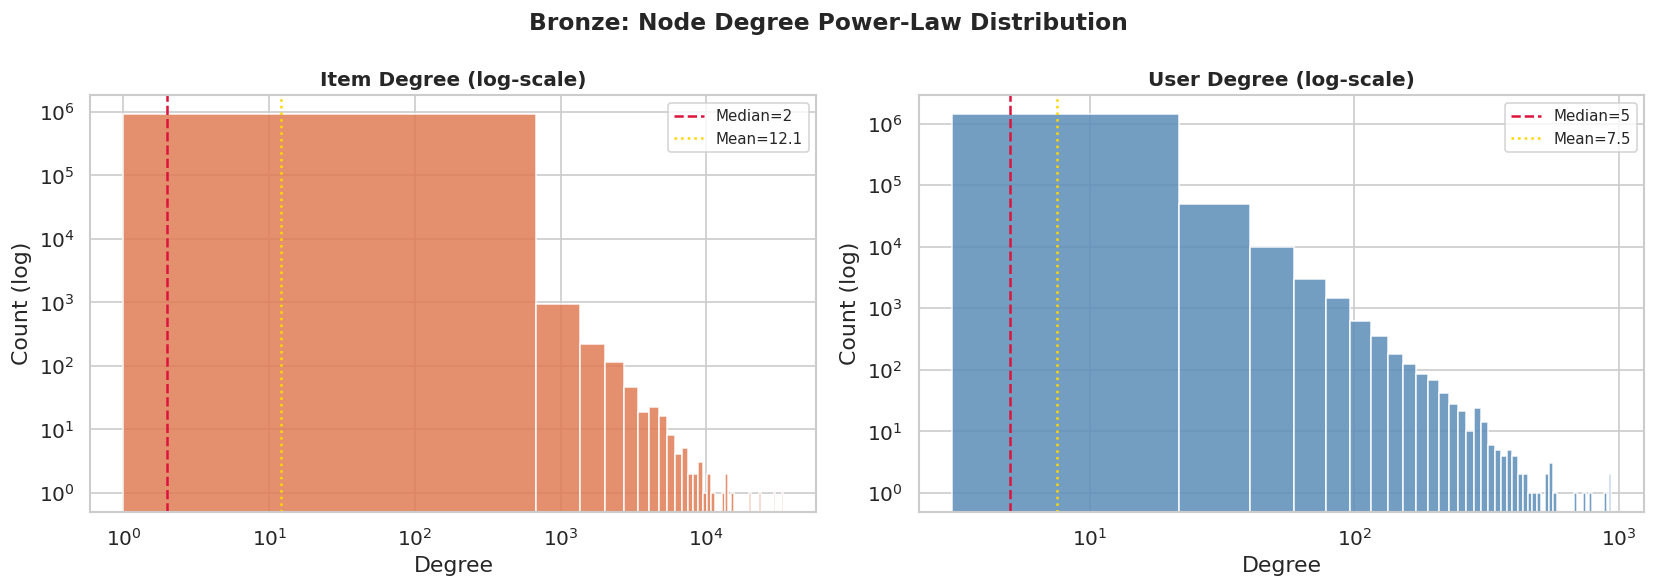

📊 Saved: eda_bronze_degree.png


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — PHÂN PHỐI BẬC NÚT (NODE DEGREE)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 3 — BẬC NÚT (NODE DEGREE)")
print("="*60)

item_deg = con.execute("""
    SELECT parent_asin, COUNT(*) AS degree
    FROM train_tbl GROUP BY parent_asin
""").df()["degree"]

user_deg = con.execute("""
    SELECT reviewer_id, COUNT(*) AS degree
    FROM train_tbl GROUP BY reviewer_id
""").df()["degree"]

for label, deg in [("ITEM degree", item_deg), ("USER degree", user_deg)]:
    print(f"\n{label}:")
    print(f"  Min={deg.min()}  Median={deg.median():.0f}  "
          f"Mean={deg.mean():.2f}  Max={deg.max()}")
    print(f"  Percentiles [25,75,90,95,99]: "
          f"{np.percentile(deg, [25,75,90,95,99]).astype(int).tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (label, deg, color) in zip(axes, [
    ("Item Degree (log-scale)", item_deg, "#e07b54"),
    ("User Degree (log-scale)", user_deg, "#5b8db8"),
]):
    ax.hist(deg, bins=50, log=True, color=color, alpha=0.85, edgecolor="white")
    ax.set_xscale("log")
    ax.set_xlabel("Degree"), ax.set_ylabel("Count (log)")
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.axvline(deg.median(), color="crimson", linestyle="--", label=f"Median={deg.median():.0f}")
    ax.axvline(deg.mean(),   color="gold",    linestyle=":",  label=f"Mean={deg.mean():.1f}")
    ax.legend(fontsize=9)
plt.suptitle("Bronze: Node Degree Power-Law Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_bronze_degree.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_bronze_degree.png")


SECTION 4 — RATING DISTRIBUTION (positive-only ≥ 3.0)
✅ Xác nhận: toàn bộ bronze_train có rating >= 3.0 (min=3.0)
 rating     cnt
    3.0  842702
    4.0 1851865
    5.0 8428858


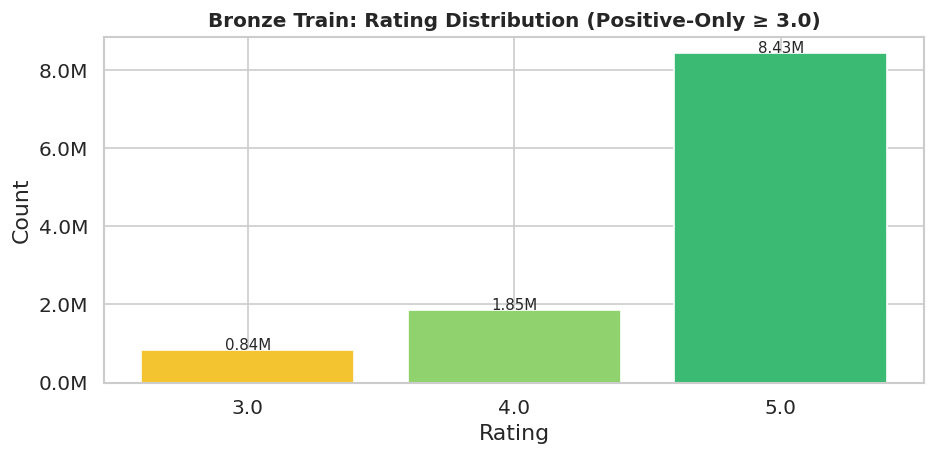

📊 Saved: eda_bronze_rating.png


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — RATING DISTRIBUTION (POSITIVE-ONLY >= 3.0)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 4 — RATING DISTRIBUTION (positive-only ≥ 3.0)")
print("="*60)

rating_df = con.execute("""
    SELECT rating, COUNT(*) AS cnt
    FROM train_tbl
    GROUP BY rating ORDER BY rating
""").df()

min_rating = con.execute("SELECT MIN(rating) FROM train_tbl").df().iloc[0,0]
assert min_rating >= 3.0, f"❌ Tồn tại rating < 3.0! min={min_rating}"
print(f"✅ Xác nhận: toàn bộ bronze_train có rating >= 3.0 (min={min_rating})")
print(rating_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    rating_df["rating"].astype(str), rating_df["cnt"],
    color=["#f4c430","#90d26d","#3bba74","#1a8a5a","#0d5e3d"][:len(rating_df)],
    edgecolor="white"
)
for bar, val in zip(bars, rating_df["cnt"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5000,
            f"{val/1e6:.2f}M", ha="center", fontsize=9)
ax.set_xlabel("Rating"), ax.set_ylabel("Count")
ax.set_title("Bronze Train: Rating Distribution (Positive-Only ≥ 3.0)", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("eda_bronze_rating.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_bronze_rating.png")


SECTION 5 — TEMPORAL ANALYSIS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

split              ts_min               ts_max
train 2001-09-10 00:21:16 33649-05-31 05:46:40
  val 2001-10-17 20:37:35 33655-10-06 05:53:20
 test 2001-11-01 21:17:37 33657-10-14 06:33:20


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


✅ Time Leakage Train > Val  : 0 (phải = 0)
✅ Time Leakage Val  > Test  : 0 (phải = 0)


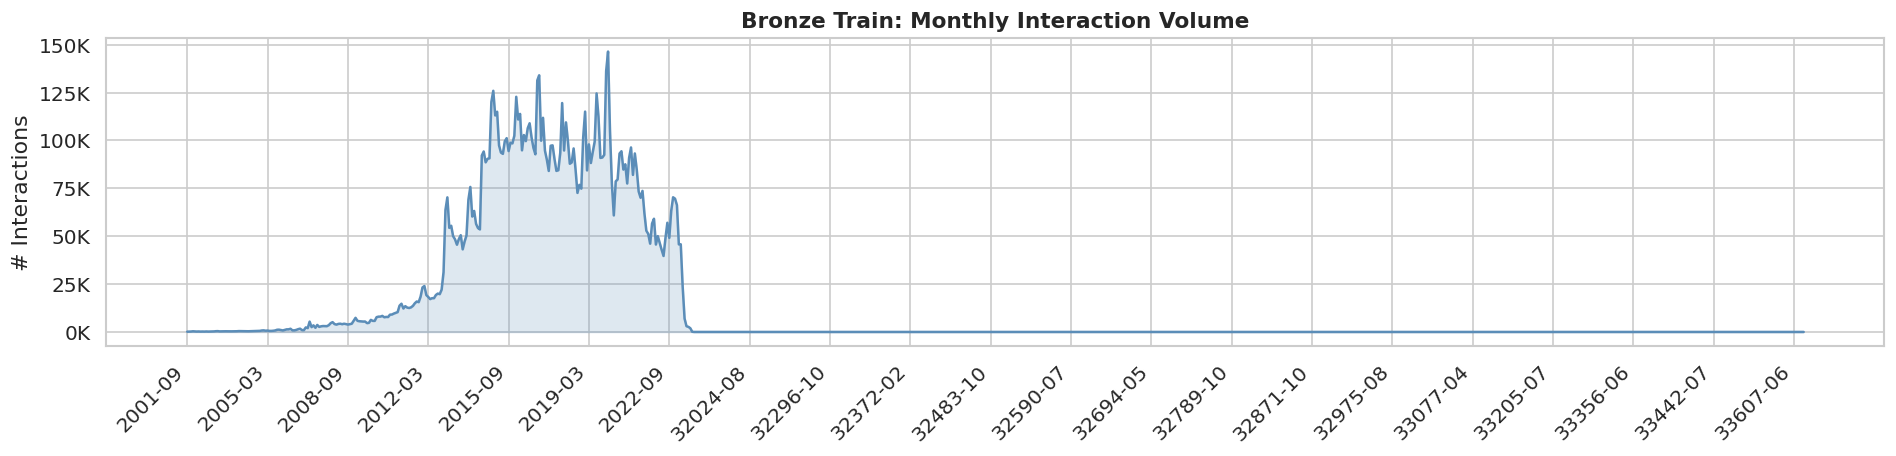

📊 Saved: eda_bronze_temporal.png


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5 — TEMPORAL ANALYSIS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 5 — TEMPORAL ANALYSIS")
print("="*60)

ts_ranges = con.execute("""
    SELECT 'train' AS split,
        epoch_ms(MIN(timestamp)*1000) AS ts_min,
        epoch_ms(MAX(timestamp)*1000) AS ts_max
    FROM train_tbl
    UNION ALL
    SELECT 'val', epoch_ms(MIN(timestamp)*1000), epoch_ms(MAX(timestamp)*1000) FROM val_tbl
    UNION ALL
    SELECT 'test', epoch_ms(MIN(timestamp)*1000), epoch_ms(MAX(timestamp)*1000) FROM test_tbl
""").df()
print(ts_ranges.to_string(index=False))

# Kiểm tra time leakage (Double Max Join)
leakage_tv = con.execute("""
    SELECT COUNT(*) AS leakage FROM (
        SELECT t.reviewer_id, MAX(t.timestamp) AS max_train, MAX(v.timestamp) AS max_val
        FROM train_tbl t JOIN val_tbl v ON t.reviewer_id = v.reviewer_id
        GROUP BY t.reviewer_id
    ) WHERE max_train > max_val
""").df().iloc[0,0]

leakage_vt = con.execute("""
    SELECT COUNT(*) AS leakage FROM (
        SELECT t.reviewer_id, MAX(t.timestamp) AS max_val, MAX(v.timestamp) AS max_test
        FROM val_tbl t JOIN test_tbl v ON t.reviewer_id = v.reviewer_id
        GROUP BY t.reviewer_id
    ) WHERE max_val > max_test
""").df().iloc[0,0]
print(f"\n✅ Time Leakage Train > Val  : {leakage_tv:,} (phải = 0)")
print(f"✅ Time Leakage Val  > Test  : {leakage_vt:,} (phải = 0)")

monthly = con.execute("""
    SELECT strftime(epoch_ms(timestamp*1000), '%Y-%m') AS ym, COUNT(*) AS cnt
    FROM train_tbl GROUP BY ym ORDER BY ym
""").df()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(range(len(monthly)), monthly["cnt"], color="#5b8db8", linewidth=1.5)
ax.fill_between(range(len(monthly)), monthly["cnt"], alpha=0.2, color="#5b8db8")
tick_step = max(1, len(monthly)//20)
ax.set_xticks(range(0, len(monthly), tick_step))
ax.set_xticklabels(monthly["ym"].iloc[::tick_step], rotation=45, ha="right")
ax.set_title("Bronze Train: Monthly Interaction Volume", fontsize=13, fontweight="bold")
ax.set_ylabel("# Interactions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.savefig("eda_bronze_temporal.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_bronze_temporal.png")



SECTION 6 — HELPFUL VOTE
  helpful_vote = 0  : 77.2%
  helpful_vote > 0  : 22.8%
  helpful_vote >= 10: 2.20%
  Max               : 32,948


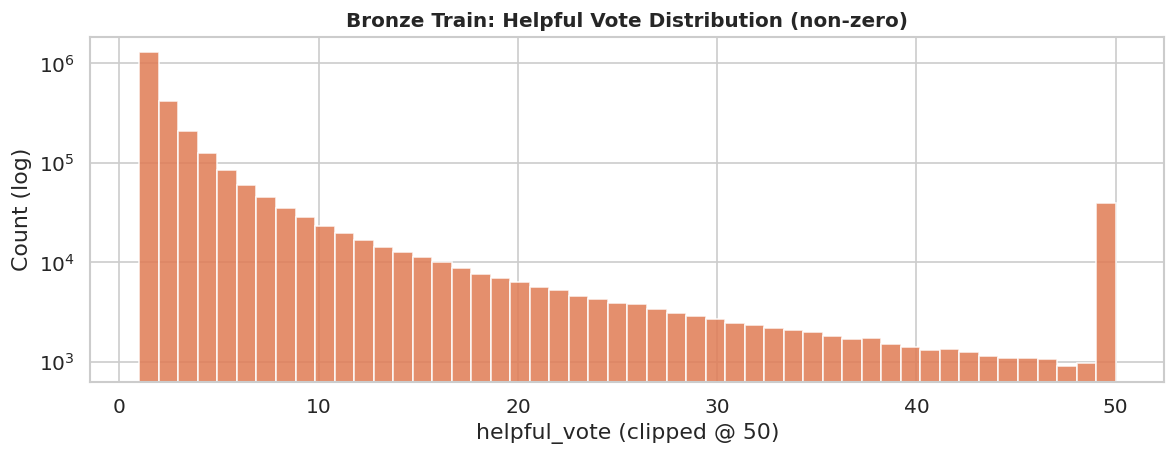

📊 Saved: eda_bronze_helpful_vote.png


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6 — HELPFUL VOTE DISTRIBUTION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 6 — HELPFUL VOTE")
print("="*60)

hv_stats = con.execute("""
    SELECT
        AVG(CASE WHEN helpful_vote = 0 THEN 1.0 ELSE 0.0 END)*100 AS pct_zero,
        AVG(CASE WHEN helpful_vote > 0 THEN 1.0 ELSE 0.0 END)*100 AS pct_nonzero,
        AVG(CASE WHEN helpful_vote >= 10 THEN 1.0 ELSE 0.0 END)*100 AS pct_gte10,
        MAX(helpful_vote) AS max_hv
    FROM train_tbl
""").df().iloc[0]
print(f"  helpful_vote = 0  : {hv_stats['pct_zero']:.1f}%")
print(f"  helpful_vote > 0  : {hv_stats['pct_nonzero']:.1f}%")
print(f"  helpful_vote >= 10: {hv_stats['pct_gte10']:.2f}%")
print(f"  Max               : {int(hv_stats['max_hv']):,}")

hv_data = con.execute("""
    SELECT LEAST(helpful_vote, 50) AS hv_clip
    FROM train_tbl WHERE helpful_vote > 0
""").df()["hv_clip"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hv_data, bins=50, color="#e07b54", edgecolor="white", alpha=0.85, log=True)
ax.set_xlabel("helpful_vote (clipped @ 50)")
ax.set_ylabel("Count (log)")
ax.set_title("Bronze Train: Helpful Vote Distribution (non-zero)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_bronze_helpful_vote.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_bronze_helpful_vote.png")


SECTION 7 — METADATA COMPLETENESS


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

title_pct          100.0
features_pct        73.7
description_pct     57.6
details_pct        100.0
categories_pct      92.0


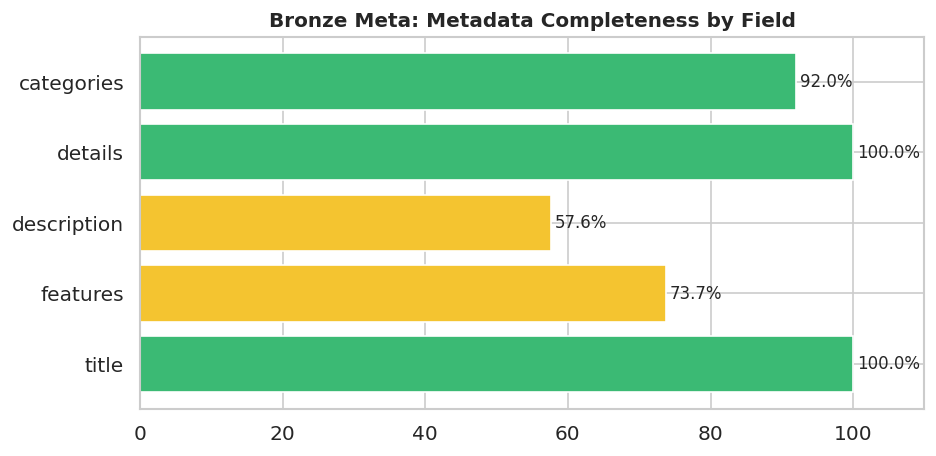

📊 Saved: eda_bronze_metadata_completeness.png


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7 — METADATA COMPLETENESS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 7 — METADATA COMPLETENESS")
print("="*60)

completeness = con.execute("""
    SELECT
        AVG(CASE WHEN title       IS NOT NULL AND TRIM(title)       != '' THEN 1.0 ELSE 0.0 END)*100 AS title_pct,
        AVG(CASE WHEN features    IS NOT NULL AND TRIM(features)    != '' THEN 1.0 ELSE 0.0 END)*100 AS features_pct,
        AVG(CASE WHEN description IS NOT NULL AND TRIM(description) != '' THEN 1.0 ELSE 0.0 END)*100 AS description_pct,
        AVG(CASE WHEN details     IS NOT NULL AND TRIM(details)     != '' THEN 1.0 ELSE 0.0 END)*100 AS details_pct,
        AVG(CASE WHEN categories  IS NOT NULL AND TRIM(categories)  != '' THEN 1.0 ELSE 0.0 END)*100 AS categories_pct
    FROM meta_tbl
""").df().iloc[0].round(1)
print(completeness.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#3bba74" if v > 80 else "#f4c430" if v > 40 else "#e07b54"
          for v in completeness.values]
bars = ax.barh(completeness.index.str.replace("_pct",""), completeness.values, color=colors)
for bar, val in zip(bars, completeness.values):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f"{val}%", va="center", fontsize=10)
ax.set_xlim(0, 110)
ax.set_title("Bronze Meta: Metadata Completeness by Field", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_bronze_metadata_completeness.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_bronze_metadata_completeness.png")


SECTION 8 — MAIN CATEGORY DISTRIBUTION
               main_category    cnt
                   Computers 418868
             All Electronics 376435
              Camera & Photo 223690
   Cell Phones & Accessories 138237
        Home Audio & Theater 106516
     Industrial & Scientific  50555
             Car Electronics  27332
    Tools & Home Improvement  24042
                 Amazon Home  21299
             Office Products  21250
              AMAZON FASHION  18391
           Sports & Outdoors  14581
                  Automotive  13956
            GPS & Navigation   9339
              Amazon Devices   8484
Portable Audio & Accessories   8050
         Musical Instruments   6668
                Toys & Games   3944
      Health & Personal Care   3073
                  All Beauty   1848


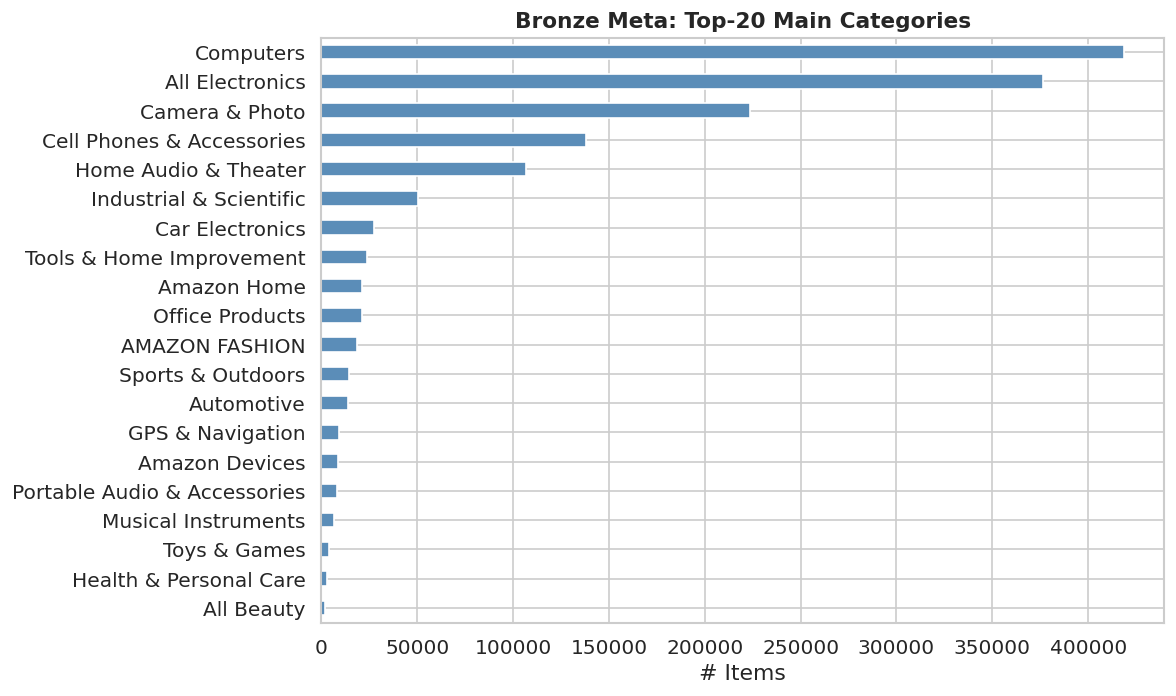

📊 Saved: eda_bronze_categories.png


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 8 — MAIN CATEGORY DISTRIBUTION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 8 — MAIN CATEGORY DISTRIBUTION")
print("="*60)

cat_df = con.execute("""
    SELECT main_category, COUNT(*) AS cnt
    FROM meta_tbl
    WHERE main_category IS NOT NULL AND main_category != ''
    GROUP BY main_category
    ORDER BY cnt DESC LIMIT 20
""").df()
print(cat_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
cat_df.sort_values("cnt").plot(kind="barh", x="main_category", y="cnt",
                               ax=ax, color="#5b8db8", edgecolor="white", legend=False)
ax.set_xlabel("# Items"), ax.set_ylabel("")
ax.set_title("Bronze Meta: Top-20 Main Categories", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_bronze_categories.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_bronze_categories.png")


SECTION 9 — REVIEW TEXT LENGTH


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

review_text words : avg=56.0  median=25.0  p90=133.0
review_title words: avg=4.4  median=3.0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

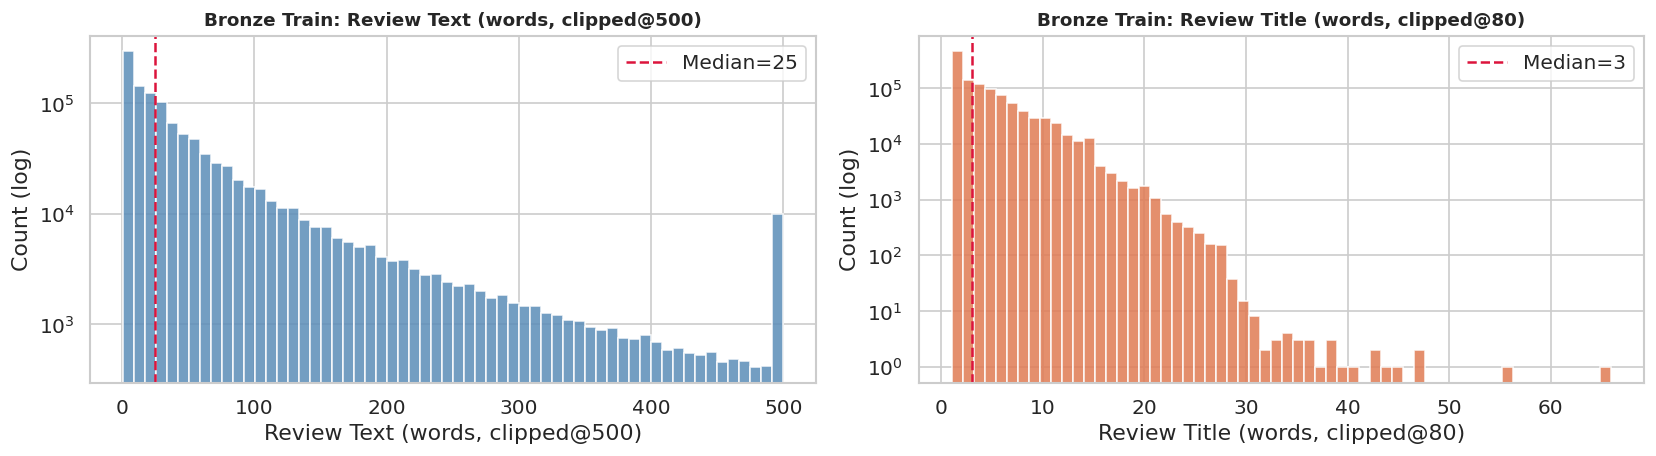

📊 Saved: eda_bronze_text_length.png


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 9 — REVIEW TEXT LENGTH (sample 10%)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("SECTION 9 — REVIEW TEXT LENGTH")
print("="*60)

text_stats = con.execute("""
    SELECT
        AVG(ARRAY_LENGTH(STRING_SPLIT(COALESCE(review_text, ''), ' ')))  AS avg_text_words,
        MEDIAN(ARRAY_LENGTH(STRING_SPLIT(COALESCE(review_text, ''), ' '))) AS median_text_words,
        PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY
            ARRAY_LENGTH(STRING_SPLIT(COALESCE(review_text, ''), ' '))) AS p90_text,
        AVG(ARRAY_LENGTH(STRING_SPLIT(COALESCE(review_title, ''), ' '))) AS avg_title_words,
        MEDIAN(ARRAY_LENGTH(STRING_SPLIT(COALESCE(review_title, ''), ' '))) AS median_title_words
    FROM train_tbl
    USING SAMPLE 10 PERCENT (bernoulli)
""").df().iloc[0].round(1)
print("review_text words :", f"avg={text_stats['avg_text_words']}  median={text_stats['median_text_words']}  p90={text_stats['p90_text']}")
print("review_title words:", f"avg={text_stats['avg_title_words']}  median={text_stats['median_title_words']}")

text_sample = con.execute("""
    SELECT
        LEAST(ARRAY_LENGTH(STRING_SPLIT(COALESCE(review_text,  ''), ' ')), 500) AS text_len,
        LEAST(ARRAY_LENGTH(STRING_SPLIT(COALESCE(review_title, ''), ' ')),  80) AS title_len
    FROM train_tbl
    USING SAMPLE 10 PERCENT (bernoulli)
""").df()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color, label in zip(
    axes,
    ["text_len", "title_len"],
    ["#5b8db8", "#e07b54"],
    ["Review Text (words, clipped@500)", "Review Title (words, clipped@80)"],
):
    data = text_sample[col]
    ax.hist(data, bins=60, color=color, alpha=0.85, edgecolor="white", log=True)
    ax.axvline(data.median(), color="crimson", linestyle="--", label=f"Median={data.median():.0f}")
    ax.set_xlabel(label), ax.set_ylabel("Count (log)")
    ax.set_title(f"Bronze Train: {label}", fontsize=11, fontweight="bold")
    ax.legend()
plt.tight_layout()
plt.savefig("eda_bronze_text_length.png", bbox_inches="tight")
plt.show()
print("📊 Saved: eda_bronze_text_length.png")

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 10 — TỔNG KẾT
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("TỔNG KẾT BRONZE EDA")
print("="*60)

summary = {
    "n_users"              : f"{n_users:,}",
    "n_items_train"        : f"{n_items_train:,}",
    "n_items_meta"         : f"{meta_items:,}",
    "n_edges_train"        : f"{n_edges_train:,}",
    "sparsity_%"           : f"{sparsity*100:.4f}%",
    "cold_start_val_%"     : f"{cold_val/max(val_items,1)*100:.2f}%",
    "cold_start_test_%"    : f"{cold_test/max(test_items,1)*100:.2f}%",
    "leakage_train_val"    : leakage_tv,
    "leakage_val_test"     : leakage_vt,
    "avg_user_degree"      : round(n_edges_train / max(n_users, 1), 2),
    "avg_item_degree"      : round(n_edges_train / max(n_items_train, 1), 2),
    "median_user_degree"   : int(user_deg.median()),
    "median_item_degree"   : int(item_deg.median()),
    "max_user_degree"      : int(user_deg.max()),
    "max_item_degree"      : int(item_deg.max()),
    "rating_min (filter)"  : float(min_rating),
}
for k, v in summary.items():
    print(f"  {k:<30} : {v}")

con.close()
print("\n✅ Bronze EDA hoàn tất!")


TỔNG KẾT BRONZE EDA
  n_users                        : 1,483,920
  n_items_train                  : 922,459
  n_items_meta                   : 1,610,012
  n_edges_train                  : 11,123,425
  sparsity_%                     : 99.9992%
  cold_start_val_%               : 17.23%
  cold_start_test_%              : 20.28%
  leakage_train_val              : 0
  leakage_val_test               : 0
  avg_user_degree                : 7.5
  avg_item_degree                : 12.06
  median_user_degree             : 5
  median_item_degree             : 2
  max_user_degree                : 938
  max_item_degree                : 33737
  rating_min (filter)            : 3.0

✅ Bronze EDA hoàn tất!
